# Imports and utility functions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import os, pickle, torch
import vima
torch.set_default_device('mps') # edit as appropriate to hardware
vima.set_seed(0) # for reproducibility
os.makedirs(f'./_results', exist_ok=True)

%run ../common.py

# Load dataset

In [7]:
# read in samples
def fname_parser(fname): 
    fname = fname.split("/")[-1].split(".nc")[0]
    if fname[-1].islower():
        donor = fname[:-1]
    else: 
        donor = fname
    return {'sid': fname, 'donor': donor}

repname = 'pca_k=10_harmony'
samples = vima.read_samples(f'../../UC/UC-data/10u/{repname}/*.nc', fname_parser)

# read in sample metadata
samplemeta = pd.read_csv('../../UC/UC-data/2024_10_16_UC_Patient_Metadata.csv').rename(columns={'NEW Label':'sid', 'Patient.ID':'donor'}).set_index('sid', drop=True)
samplemeta.donor = samplemeta.donor.astype('str')

# add in phenotypes
samplemeta['UC'] = (samplemeta.Status == 'UC').astype('float')
samplemeta.loc[(samplemeta.TNFnow == 'y') | (samplemeta.TNFprior == 'y'), 'UC'] = np.nan
samplemeta['TNF'] = (samplemeta.TNFprior == 'y').astype('float')
samplemeta.loc[samplemeta.UC == 0, 'TNF'] = np.nan

100%|███████████████████████████████████████████████████████████████| 42/42 [00:01<00:00, 35.57it/s]


In [3]:
# choose which patches to train on
P = vima.PatchCollection(samples)
print(len(P), 'patches')

# choose which patches to do case/ctrl analysis on
Pdense = vima.PatchCollection(samples, max_frac_empty=0.5, sid_nums=P.sid_nums)
print(len(Pdense), 'dense patches')

100%|███████████████████████████████████████████████████████████████| 42/42 [00:03<00:00, 12.70it/s]


in pytorch mode
means: [ 0.05447359  0.00932357 -0.01125651 -0.08395857 -0.0760752  -0.00231467
  0.02149703 -0.02244353  0.03177896  0.03401043]
stds: [2.762697   1.6159511  1.5329615  0.98749584 0.7044896  0.695698
 0.84755    0.71394193 0.84401417 0.70302254]
data augmentation is off
25869 patches


100%|███████████████████████████████████████████████████████████████| 42/42 [00:02<00:00, 16.30it/s]


in pytorch mode
means: [ 0.02617896 -0.01365452 -0.02929876 -0.0981875  -0.08734448 -0.00903606
  0.02480437 -0.02955827  0.02544119  0.02641205]
stds: [2.8995552  1.7140516  1.6182748  1.0435452  0.7490146  0.73932135
 0.8920543  0.7566857  0.8822612  0.74306035]
data augmentation is off
21359 dense patches


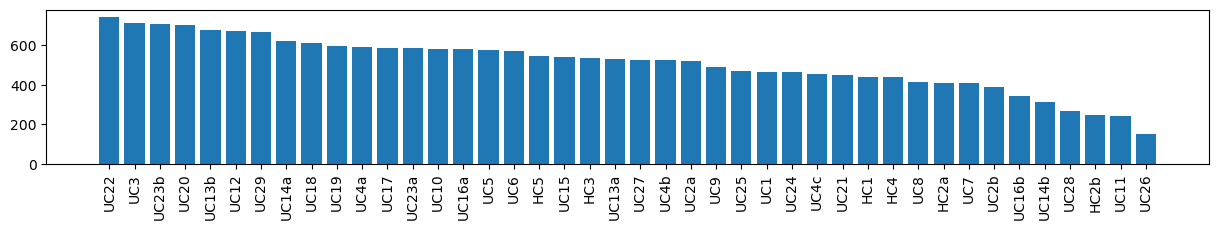

42it [00:02, 20.14it/s]
/Users/yakir/Dropbox/py/vima/src/vima/data/samples.py:90: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


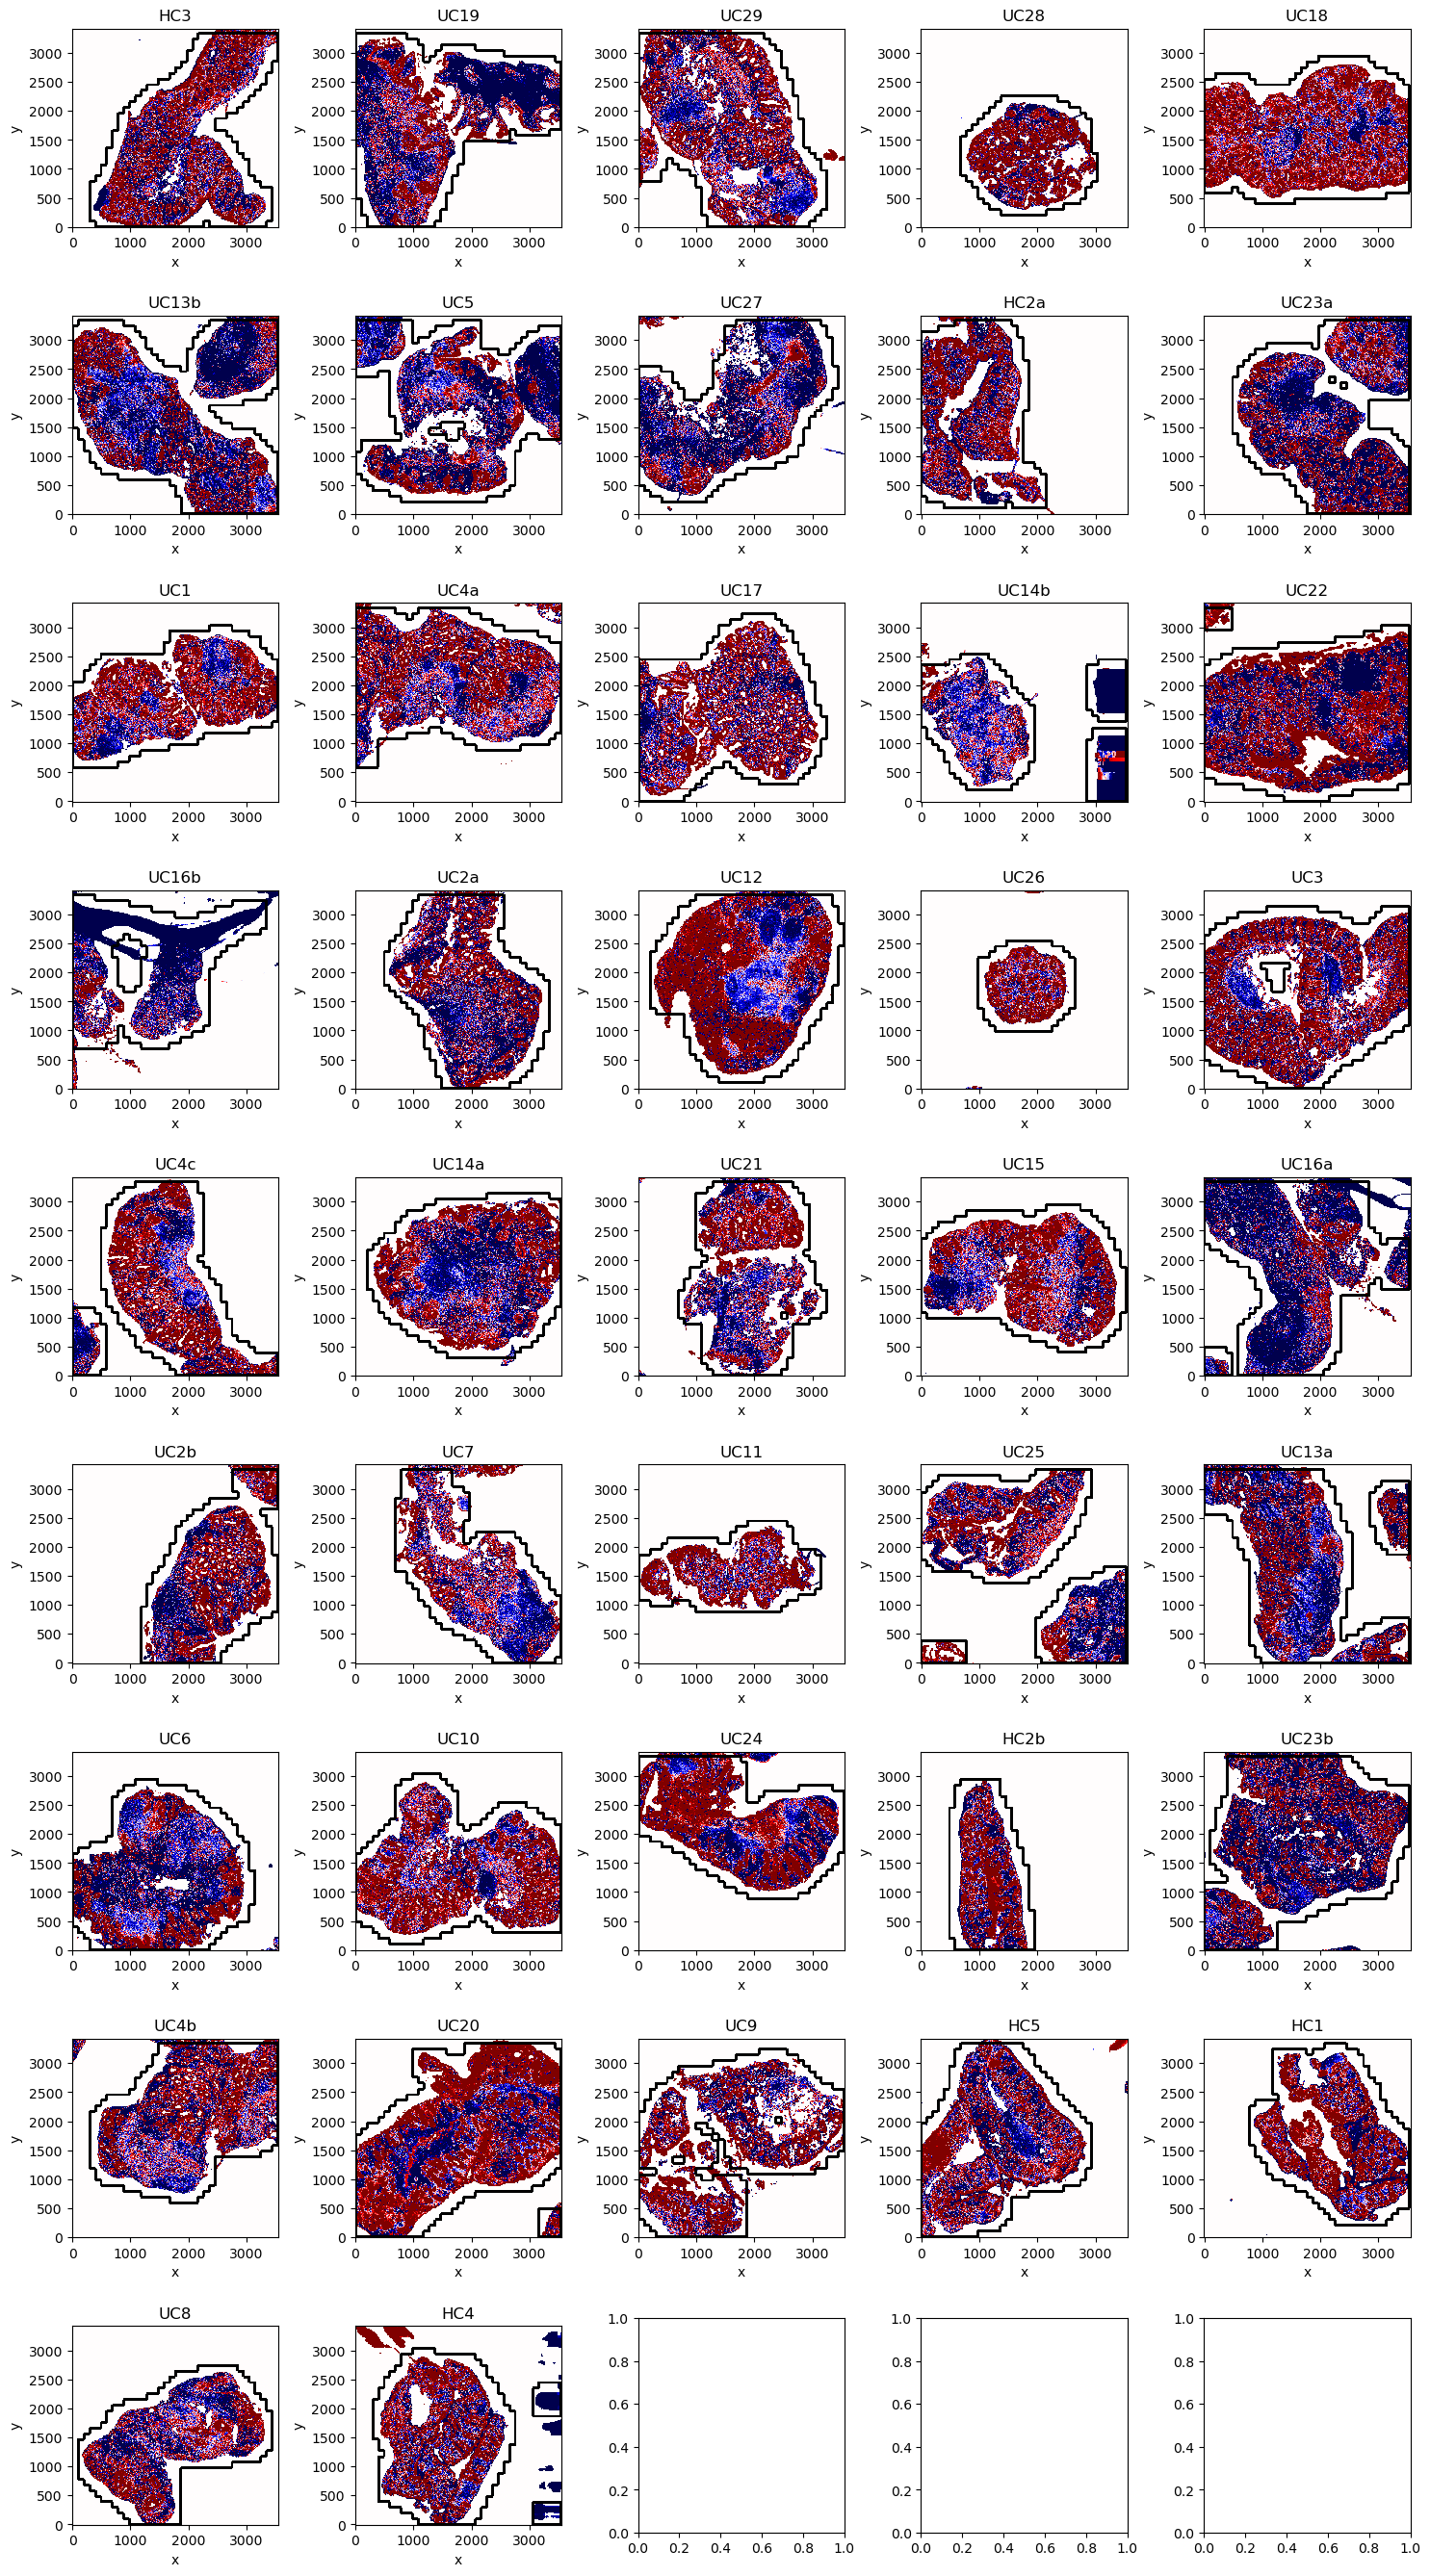

In [4]:
# visualize resulting patches
vima.d.plot_npatches_per_sample(samples, Pdense.meta)
vima.d.plot_samples_with_patches(samples.values(), 'hPC1', Pdense.meta, ncols=5, vmin=-2, vmax=2, cmap='seismic')

# Train VAE

end of epoch 20: avg val loss = 0.6435120820999145
time elapsed this epoch: 178.29 sec
total time elapsed: 3658.03 sec


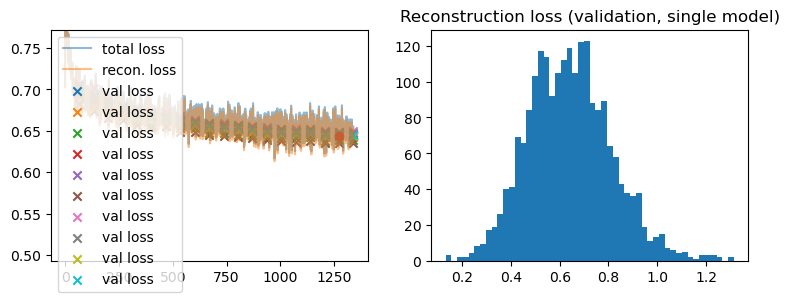

best validation losses so far across full model ensemble: [0.64418525, 0.64263934, 0.6381889, 0.64455205, 0.6449155, 0.6346321, 0.6482349, 0.6474173, 0.6428614, 0.6447613]
best epochs so far across full model ensemble: [20, 20, 18, 20, 20, 19, 19, 20, 19, 20]


In [5]:
models = vima.models.cVAE(P.nmarkers, P.nsamples)

log = vima.train(models, P, n_epochs=10)
log2 = vima.train(models, Pdense, n_epochs=20)
torch.save(models.state_dict(), f'_results/models.pt')

In [6]:
# load model
models = vima.models.cVAE(P.nmarkers, P.nsamples)
models.load_state_dict(torch.load(f'_results/models.pt'))

# apply models and build nearest-neighbor graphs
ds = vima.latentreps(models, Pdense)
pickle.dump(ds, open(f'_results/fingerprints.pkl', 'wb'))

applying models
in pytorch mode
data augmentation is off


100%|███████████████████████████████████████████████████████████████| 22/22 [00:16<00:00,  1.33it/s]


computing nearest-neighbor graphs


100%|███████████████████████████████████████████████████████████████| 10/10 [00:29<00:00,  3.00s/it]


# Analyze

In [3]:
ds = pickle.load(open(f'_results/fingerprints.pkl', 'rb'))

## UC vs healthy

computing MAMs
performing association test
P = 0.0016998300169983002


/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


         Falling back to preprocessing with `sc.pp.pca` and default params.
found 11839 microniches at FDR 10%


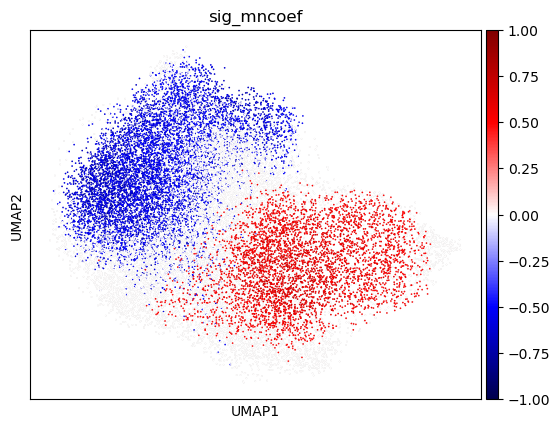

In [ ]:
p, D = vima.association(ds, samplemeta.UC, 'sid', donorids=samplemeta.donor)
print(f'found {(D.obs.mncoef_fdr <= 0.1).sum()} microniches at FDR 10%')

D.obs['sig_mncoef'] = D.obs.mncoef.where(D.obs.mncoef_fdr <= 0.1, 0)
sc.pl.umap(D, ax=plt.gca(), show=False)
sc.pl.umap(D[D.obs.sig_mncoef != 0], color='sig_mncoef', cmap='seismic', vmin=-1, vmax=1, ax=plt.gca())

In [15]:
# count number of patches of each type per sample and save
samplemeta['npatches'] = D.obs.sid.value_counts()
samplemeta[['UC_nneg', 'UC_npos']] = pd.crosstab(D.obs.sid, D.obs.sig_mncoef.map(
                                    lambda x: 0 if x < 0 else (1 if x > 0 else np.nan)
                                ))

D.uns['samplemeta'] = samplemeta
D.write(f'_results/cc_uc.h5ad')

## TNF vs no

In [16]:
ds_sig = [
    d[D.obs.sig_mncoef > 0].copy() for d in ds
]
for d in ds_sig:
    sc.pp.neighbors(d, use_rep='X')

/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Users/yakir/miniconda3/envs/torch/lib/python3.12/site-packages/anndata/_core/aligned_df.py:

computing MAMs
performing association test
P = 0.0014998500149985001
         Falling back to preprocessing with `sc.pp.pca` and default params.
found 2307 microniches at FDR 10%


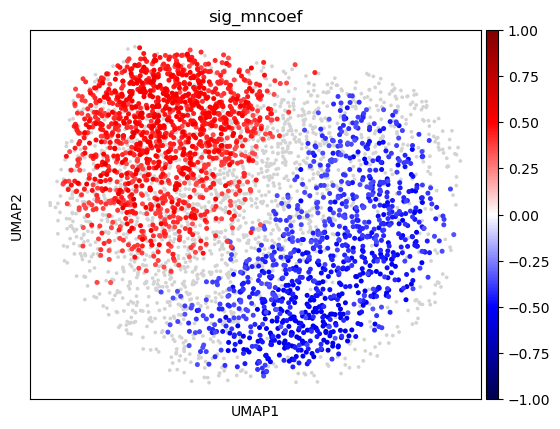

In [21]:
ptnf, Dtnf = vima.association(ds_sig, samplemeta.TNF, 'sid', donorids=samplemeta.donor)
print(f'found {(Dtnf.obs.mncoef_fdr <= 0.1).sum()} microniches at FDR 10%')

Dtnf.obs['sig_mncoef'] = Dtnf.obs.mncoef.where(Dtnf.obs.mncoef_fdr <= 0.1, 0)
sc.pl.umap(Dtnf, ax=plt.gca(), show=False)
sc.pl.umap(Dtnf[Dtnf.obs.sig_mncoef != 0], color='sig_mncoef', cmap='seismic', vmin=-1, vmax=1, ax=plt.gca())

In [22]:
# count number of patches of each type per sample and save
samplemeta['TNF_npatches'] = Dtnf.obs.sid.value_counts()
samplemeta[['TNF_nneg', 'TNF_npos']] = pd.crosstab(Dtnf.obs.sid, Dtnf.obs.sig_mncoef.map(
                                    lambda x: 0 if x < 0 else (1 if x > 0 else np.nan)
                                ))

Dtnf.uns['samplemeta'] = samplemeta
Dtnf.write(f'_results/cc_tnf.h5ad')

In [23]:
df = Dtnf.uns['samplemeta'][['Status', 'TNFprior', 'TNFnow', 'TNF_npatches', 'TNF_nneg', 'TNF_npos']]
df = df[df.Status == 'UC']
df['TNF_frac_pos'] = df.TNF_npos / (df.TNF_npatches)
df['TNF_frac_neg'] = df.TNF_nneg / (df.TNF_npatches)
df.drop(columns=['Status']).to_csv('_results/tnf_npatches.csv')

## TNF vs no using clusters

In [ ]:
D = sc.read_h5ad(f'_results/cc_uc.h5ad')
Dsig = D[D.obs.sig_mncoef > 0].copy()
sc.tl.umap(Dsig)
sc.tl.leiden(Dsig, resolution=0.33, key_added='leiden', seed=0)

Dtnf = sc.read_h5ad(f'_results/cc_tnf.h5ad')
Dtnf.obs['leiden'] = Dsig.obs.leiden
Dtnf.obs.leiden.value_counts()

leiden
0    2640
1    1506
Name: count, dtype: int64

In [8]:
# add relative cluster abundances
cluster_sample_counts = pd.crosstab(Dtnf.obs.leiden, Dtnf.obs.sid)
cluster_sample_fracs = cluster_sample_counts.div(cluster_sample_counts.sum(axis=0), axis=1)
for cluster in sorted(Dtnf.obs.leiden.unique()):
    samplemeta[f'leiden_{cluster}_frac'] = cluster_sample_fracs.loc[cluster]
samplemeta.to_csv('_results/tnf_clusterbased.csv')
Dtnf.write('_results/cc_tnf.h5ad')

## Collate benchmarking results (requires benchmarking to have been run)

In [4]:
D = sc.read_h5ad('_results/cc_uc.h5ad')
collate_cc('UC', D=D, outpath='_results/benchmarking.csv')

stagate noharm
patchavgmm noharm
patchcelltypeabundance noharm
tissuemosaic noharm
canvas noharm
utag noharm
canvas harm
patchcelltypeabundance harm
utag harm
patchavgmm harm
stagate harm
tissuemosaic harm


,microniche,harmonized,bonferroni,p,npos,nneg,ntotal,frac_pos,frac_neg
method,,,,,,,,,
patchavgmm,True,True,False,0.000200,11,604,21359,0.000515,0.028278
vima,NaN,NaN,NaN,0.001700,4146,7693,21359,0.194110,0.360176
patchavgmm,False,True,False,0.001700,781,1958,21359,0.036565,0.091671
patchavgmm,False,False,False,0.002700,0,1551,21359,0.000000,0.072616
patchavgmm,True,False,False,0.003100,1,268,21359,0.000047,0.012547
patchcelltypeabundance,True,True,False,0.006199,1,1017,21359,0.000047,0.047615
utag,False,True,True,0.006899,0,133269,1647673,0.000000,0.080883
canvas,False,True,False,0.008899,0,306,2101,0.000000,0.145645
canvas,False,True,True,0.009599,0,306,2101,0.000000,0.145645
